# **Sentiment Analysis based Stock Market Recommendation System using Two Phase Approach**

## **Stock Market Fundamental Analysis**

**Model Used :**
**FInBert**

Stock News Analysis using FinBert to predict next day stock direction

**Steps :**

**1) Data collection and dataset information:**

The data collection process involves using the Alpha Vantage API to gather news sentiment data specifically related to the AAPL stock. The API is queried to retrieve the top 50 latest news articles within the last two days, focusing on the topic of technology. The fetched data is then stored in a Pandas DataFrame, which includes various information such as title, headlines, summaries, url. By gathering this data, we aim to analyze the sentiment trends and their potential impact on the AAPL stock. This dataset provides valuable insights into market sentiment and can be used for further analysis and prediction purposes.

**2) Data preprocessing:**

In the data preprocessing step, the collected news articles in JSON format are processed to remove unnecessary brackets from the headlines and summaries. Regular expressions are applied to clean the text by removing any content enclosed within parentheses. This ensures that the headlines and summaries are free from irrelevant information. The cleaned headlines and summaries are then ready for subsequent analysis, such as sentiment analysis or topic modeling, without the presence of unnecessary brackets that may interfere with the accuracy of the results.

**3) Model development:**

The code focuses on the utilization of the FinBERT model, which is a transformer-based model specifically designed for financial sentiment analysis. The FinBERT model is imported and initialized using the AutoTokenizer and AutoModelForSequenceClassification classes from the Transformers library. These classes provide the necessary tools to tokenize the input data, which in this case, consists of cleaned article texts. The tokenizer breaks down the texts into tokens and performs necessary encoding steps, such as adding special tokens and generating attention masks. The resulting tokenized texts are then converted into PyTorch tensors, enabling efficient processing and utilization within the FinBERT model. This allows the model to capture the nuanced sentiment present in the financial articles and make predictions based on the learned representations.

**4) Model training:**

The FinBERT model used in this project is a pre-trained model that has already undergone extensive training on a large financial sentiment dataset. It has learned to capture the nuances and patterns in financial language and sentiment. Therefore, in this project, the model is not trained from scratch but rather utilized as a pre-trained model for sentiment analysis tasks. The pre-training process involves training the model on a large corpus of financial text data, allowing it to learn representations that capture the specific characteristics of financial sentiment. As a result, the model already possesses the knowledge and understanding of financial sentiment, and further training on the provided dataset is not necessary. The trained model can be directly applied to predict sentiment on new financial texts, providing accurate and insightful sentiment analysis for financial data.

**5) Model evaluation:**

The model evaluation stage involves predicting sentiment scores for news articles using the FinBERT model. The sentiment predictions are categorized as positive, negative, or neutral. The model's logits are passed through a softmax function to obtain probability scores for each sentiment class. These scores, along with the article headlines, are organized into a DataFrame. The overall sentiment score is calculated by summing the cumulative sentiment scores of all the articles. Based on the sign of the overall sentiment score, the model determines the predicted stock direction for the next day, whether it will go up or down. The overall sentiment score and predicted stock direction are then printed as the evaluation results. This process allows for assessing the sentiment of news articles and using it to make predictions about the stock market.


In [14]:
# Import packages

import pandas as pd
import requests
from datetime import datetime, timedelta

In [15]:
# Using Alphavantage for fetching the news
# documentation : https://www.alphavantage.co/documentation/


In [16]:
# URL which considers symbol for specific stock, duration as from one day from the current date till current date, bydefault latest news, limit is top 20, and topic is technology
# time format : #YYYYMMDDTHHMM
#Basic url = 'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&tickers=AAPL&apikey=API_KEY'
# limit not added but bydefault is 50 news

stock_symbol = "AAPL"
API_KEY = "I4OIMMPFUBLACCN6"
# Calculate the date range for the last two days until the current date
today = datetime.now().strftime("%Y%m%d")
two_days_ago = (datetime.now() - timedelta(days=2)).strftime("%Y%m%d")

url = f"https://www.alphavantage.co/query?function=NEWS_SENTIMENT&tickers={stock_symbol}&apikey={API_KEY}&topics=technology&time_from={two_days_ago}T0100&time_to={today}T2300&"

r = requests.get(url)
data = r.json()

In [17]:
# Convert the Python object into a DataFrame
df = pd.DataFrame(data)

In [18]:
df.head(5)

,items,sentiment_score_definition,relevance_score_definition,feed
0,50,x <= -0.35: Bearish; -0.35 < x <= -0.15: Somew...,"0 < x <= 1, with a higher score indicating hig...",{'title': 'Market Clubhouse Morning Memo - Jun...
1,50,x <= -0.35: Bearish; -0.35 < x <= -0.15: Somew...,"0 < x <= 1, with a higher score indicating hig...",{'title': '4 Green Flags for Unity Software's ...
2,50,x <= -0.35: Bearish; -0.35 < x <= -0.15: Somew...,"0 < x <= 1, with a higher score indicating hig...",{'title': 'Apple Stock Nears $3-Trillion Marke...
3,50,x <= -0.35: Bearish; -0.35 < x <= -0.15: Somew...,"0 < x <= 1, with a higher score indicating hig...","{'title': 'Stock Market News for Jun 28, 2023'..."
4,50,x <= -0.35: Bearish; -0.35 < x <= -0.15: Somew...,"0 < x <= 1, with a higher score indicating hig...",{'title': 'Happy Birthday Elon Musk: 52 Facts ...


In [19]:
df.count()

items                         50
sentiment_score_definition    50
relevance_score_definition    50
feed                          50
dtype: int64

In [20]:
df["feed"][0]

{'title': 'Market Clubhouse Morning Memo - June 28th, 2023  ( Trade Strategy For SPY, QQQ, AAPL, TSLA, NVDA, And META )  - Invesco QQQ Trust, Series 1  ( NASDAQ:QQQ ) ',
 'url': 'https://www.benzinga.com/23/06/33044331/market-clubhouse-morning-memo-june-28th-2023-trade-strategy-for-spy-qqq-aapl-tsla-nvda-and-meta',
 'time_published': '20230628T144543',
 'authors': ['RIPS'],
 'summary': "Good Morning Traders! In today's Market Clubhouse Morning Memo, we will discuss SPY, QQQ, AAPL, TSLA, NVDA, and META. Our proprietary formula, exclusive to Market Clubhouse, dictates these price levels. This dynamic equation takes into account price, volume, and options flow.",
 'banner_image': 'https://cdn.benzinga.com/files/market-clubhouse-morning-memo_13.png?width=1200&height=800&fit=crop',
 'source': 'Benzinga',
 'category_within_source': 'Trading',
 'source_domain': 'www.benzinga.com',
 'topics': [{'topic': 'Economy - Monetary', 'relevance_score': '0.158519'},
  {'topic': 'Financial Markets', 'rel

In [21]:
print(df["feed"][0]["title"])
print(df["feed"][0]["time_published"])
print(df["feed"][0]["summary"])
'''
for i in range(df["feed"].count()):                            # To check the news published dates
  print(df["feed"][i]["time_published"])
'''

Market Clubhouse Morning Memo - June 28th, 2023  ( Trade Strategy For SPY, QQQ, AAPL, TSLA, NVDA, And META )  - Invesco QQQ Trust, Series 1  ( NASDAQ:QQQ ) 
20230628T144543
Good Morning Traders! In today's Market Clubhouse Morning Memo, we will discuss SPY, QQQ, AAPL, TSLA, NVDA, and META. Our proprietary formula, exclusive to Market Clubhouse, dictates these price levels. This dynamic equation takes into account price, volume, and options flow.


'\nfor i in range(df["feed"].count()):                            # To check the news published dates\n  print(df["feed"][i]["time_published"])\n'

In [25]:
# creating new article list where combining the title and summary together

articles_list = []

count = df["feed"].count()

for i in range(count):
  articles_list.append(df["feed"][i]["title"] + " : " + df["feed"][i]["summary"])

df1 = pd.DataFrame(articles_list)
df1.head()

,0
0,"Market Clubhouse Morning Memo - June 28th, 202..."
1,4 Green Flags for Unity Software's Future : Th...
2,Apple Stock Nears $3-Trillion Market Cap: Anal...
3,"Stock Market News for Jun 28, 2023 : Wall Stre..."
4,Happy Birthday Elon Musk: 52 Facts And Figures...


In [32]:
# Removing all the unnecessary brackets
import re

cleaned_articles_list = []

# Iterate over each text in the list
for text in articles_list:
    cleaned_text = re.sub(r'\([^)]*\)', '', text)
    cleaned_articles_list.append(cleaned_text)

'''
df2 = pd.DataFrame(cleaned_articles_list)
df2.head()
'''
'''
# Removing all the punctuations from the list like fullstop or brackets

import re

cleaned_articles_list = []

# Define the regular expression pattern
pattern = r'[^\w\s]|\[|\]'

# Iterate over each text in the list
for text in articles_list:
    cleaned_text = re.sub(pattern, '', text)
    cleaned_articles_list.append(cleaned_text)

# Print the cleaned_articles_list
for cleaned_text in cleaned_articles_list:
    print(cleaned_text)
'''

"\n# Removing all the punctuations from the list like fullstop or brackets\n\nimport re\n\ncleaned_articles_list = []\n\n# Define the regular expression pattern\npattern = r'[^\\w\\s]|\\[|\\]'\n\n# Iterate over each text in the list\nfor text in articles_list:\n    cleaned_text = re.sub(pattern, '', text)\n    cleaned_articles_list.append(cleaned_text)\n\n# Print the cleaned_articles_list\nfor cleaned_text in cleaned_articles_list:\n    print(cleaned_text)\n"

In [33]:
# Start with Trnasformers

!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 61.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 31.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 99.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.0 MB/s eta 0:00:00


In [34]:
# Import Finbert model
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Move the model to the GPU
#GPU----------------------------
#model.to(device)
#inputs = inputs.to(device)
#------------------------------

In [35]:
# Add input cleaned_articles_list to finbert model
inputs = tokenizer(cleaned_articles_list, padding = True, truncation = True, return_tensors='pt')

# print(inputs)

In [36]:
# Generate the outputs

outputs = model(**inputs)

#outputs = model(**inputs.to(device))
print(outputs.logits.shape)

torch.Size([50, 3])


In [37]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

#print(predictions)

In [38]:
# Print the results

import pandas as pd

positive = predictions[:, 0].tolist()
negative = predictions[:, 1].tolist()
neutral = predictions[:, 2].tolist()

table = {'Headline':cleaned_articles_list,
         "Positive":positive,
         "Negative":negative,
         "Neutral":neutral}

df = pd.DataFrame(table, columns = ["Headline", "Positive", "Negative", "Neutral"])

df.head(5)

,Headline,Positive,Negative,Neutral
0,"Market Clubhouse Morning Memo - June 28th, 202...",0.033328,0.018377,0.948295
1,4 Green Flags for Unity Software's Future : Th...,0.894246,0.025069,0.080686
2,Apple Stock Nears $3-Trillion Market Cap: Anal...,0.626329,0.027292,0.346380
3,"Stock Market News for Jun 28, 2023 : Wall Stre...",0.881174,0.096339,0.022487
4,Happy Birthday Elon Musk: 52 Facts And Figures...,0.042821,0.035096,0.922084


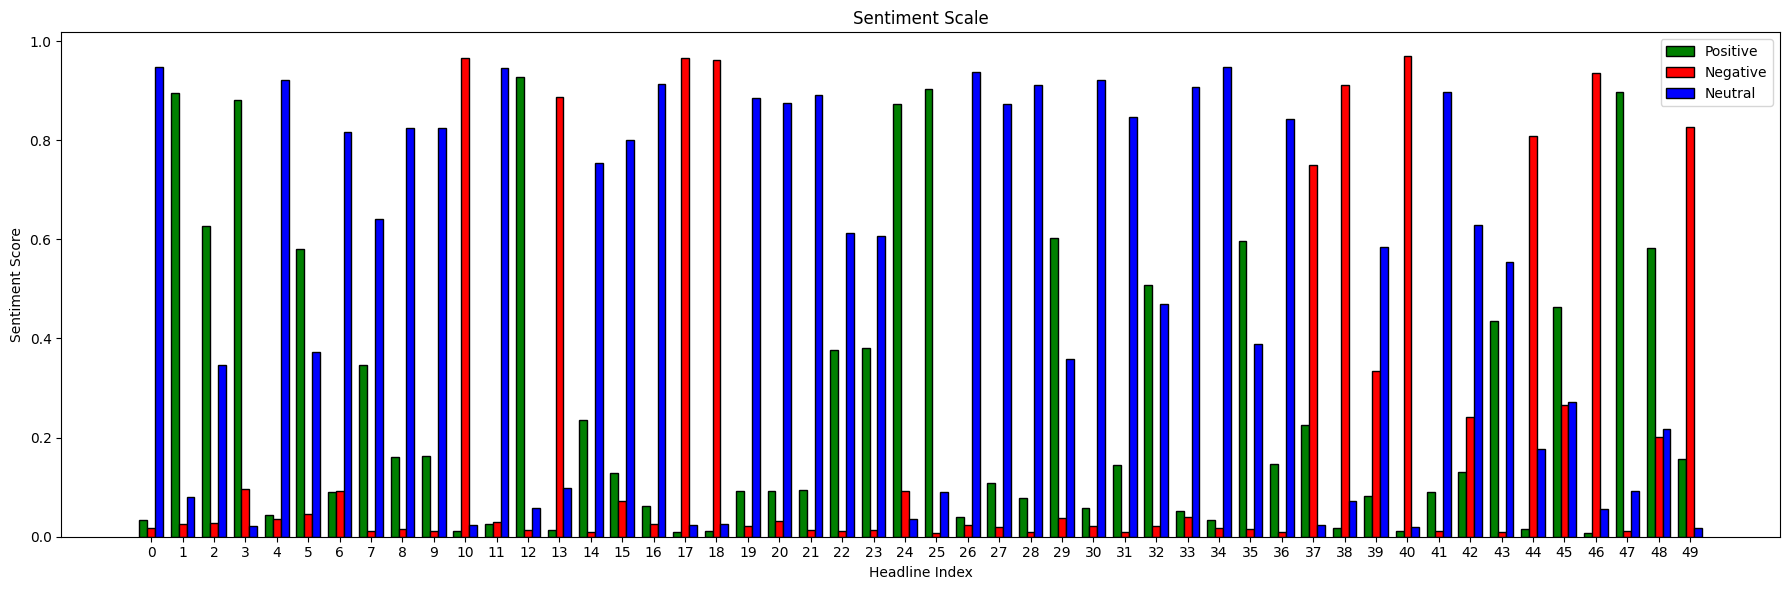

In [39]:
# Visualize the sentiment for each headline

import pandas as pd
import matplotlib.pyplot as plt

# Prepare the data for plotting
headlines = df["Headline"]
positive_scores = df["Positive"]
negative_scores = df["Negative"]
neutral_scores = df["Neutral"]

# Set the width of the bars
bar_width = 0.25

# Set the positions of the bars on the x-axis
r1 = range(len(df))
r2 = [x + bar_width for x in r1]
r3 = [x + 2 * bar_width for x in r1]

# Plot the sentiment scale
plt.figure(figsize=(18, 6))  # Adjust the figure size
plt.bar(r1, positive_scores, color='g', width=bar_width, edgecolor='black', label='Positive')
plt.bar(r2, negative_scores, color='r', width=bar_width, edgecolor='black', label='Negative')
plt.bar(r3, neutral_scores, color='b', width=bar_width, edgecolor='black', label='Neutral')

# Add x-axis labels
plt.xlabel('Headline Index')
plt.xticks([r + bar_width for r in range(len(df))], r1)  # Use index values as labels

# Add y-axis label
plt.ylabel('Sentiment Score')

# Add chart title
plt.title('Sentiment Scale')

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [40]:
# Add a new column for sentiment based on the highest value

df["Overall_Sentiment"] = df[["Positive", "Negative", "Neutral"]].idxmax(axis=1)
df["Overall_Sentiment"] = df["Overall_Sentiment"].apply(lambda x: x.capitalize())

df.head(5)

,Headline,Positive,Negative,Neutral,Overall_Sentiment
0,"Market Clubhouse Morning Memo - June 28th, 202...",0.033328,0.018377,0.948295,Neutral
1,4 Green Flags for Unity Software's Future : Th...,0.894246,0.025069,0.080686,Positive
2,Apple Stock Nears $3-Trillion Market Cap: Anal...,0.626329,0.027292,0.346380,Positive
3,"Stock Market News for Jun 28, 2023 : Wall Stre...",0.881174,0.096339,0.022487,Positive
4,Happy Birthday Elon Musk: 52 Facts And Figures...,0.042821,0.035096,0.922084,Neutral


In [41]:
# Calculate the count of positive, negative, and neutral values
sentiment_counts = df["Overall_Sentiment"].value_counts()

# Print the count of each sentiment
print("Sentiment Counts:")
print(sentiment_counts)

Sentiment Counts:
Neutral     27
Positive    13
Negative    10
Name: Overall_Sentiment, dtype: int64


In [45]:
# Calculate cumulative sentiment scores

df["Cumulative Sentiment"] = df["Positive"] - df["Negative"]

df

,Headline,Positive,Negative,Neutral,Overall_Sentiment,Cumulative Sentiment
0,"Market Clubhouse Morning Memo - June 28th, 202...",0.033328,0.018377,0.948295,Neutral,0.014951
1,4 Green Flags for Unity Software's Future : Th...,0.894246,0.025069,0.080686,Positive,0.869177
2,Apple Stock Nears $3-Trillion Market Cap: Anal...,0.626329,0.027292,0.346380,Positive,0.599037
3,"Stock Market News for Jun 28, 2023 : Wall Stre...",0.881174,0.096339,0.022487,Positive,0.784835
4,Happy Birthday Elon Musk: 52 Facts And Figures...,0.042821,0.035096,0.922084,Neutral,0.007725
5,How Is The Market Feeling About Apple? - Apple...,0.579558,0.046832,0.373610,Positive,0.532727
6,Futures Mixed Ahead Of Powell Discussion : Dow...,0.090955,0.092589,0.816456,Neutral,-0.001635
7,3 Top BlackRock Mutual Funds Worth a Buy for B...,0.346482,0.011665,0.641853,Neutral,0.334817
8,Apple to Hit $4-Tn Market Cap in 2024? ETFs in...,0.161106,0.014604,0.824290,Neutral,0.146503
9,From iMac To IoT: Connecting A Smart New World...,0.163486,0.011310,0.825204,Neutral,0.152176


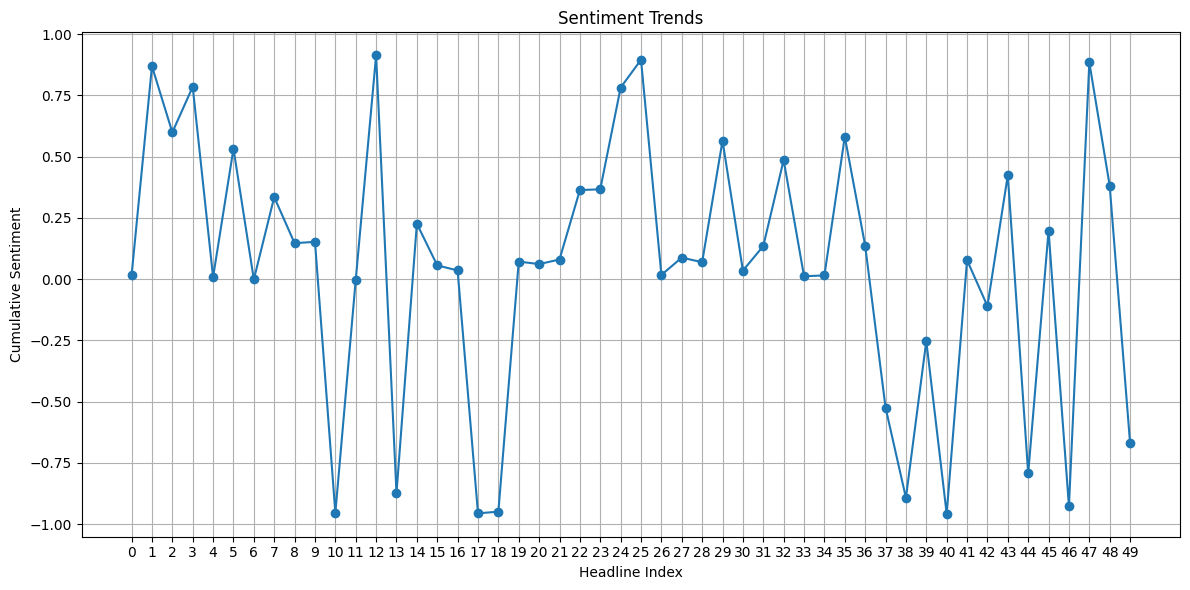

In [43]:
#Visualize based on Cumulative Sentiment score

# Prepare the data for plotting
dates = range(len(df))
sentiments = df["Cumulative Sentiment"]

# Plot the sentiment trends
plt.figure(figsize=(12, 6))  # Increase the width of the graph
plt.plot(dates, sentiments, marker="o")
plt.xlabel("Headline Index")
plt.ylabel("Cumulative Sentiment")
plt.title("Sentiment Trends")
plt.xticks(dates, range(len(df)))  # Label headlines as 0, 1, 2, ...
plt.grid(True)
plt.tight_layout()  # Adjust the layout to avoid overlapping labels
plt.show()


In [44]:
# Predicting the stock direction for next day

import pandas as pd


# Cumulative Sentiment score calculated already : df["Cumulative Sentiment"] = df["Positive"] - df["Negative"]

# Calculate the overall sentiment score
overall_sentiment_score = df["Cumulative Sentiment"].sum()

# Determine the overall sentiment direction
if overall_sentiment_score > 0:
    stock_direction = "Up"
elif overall_sentiment_score < 0:
    stock_direction = "Down"
else:
    stock_direction = "Neutral"

print("Overall Sentiment Score:", overall_sentiment_score)
print("Predicted Stock Direction for Next Day:", stock_direction)

Overall Sentiment Score: 2.5292589738965034
Predicted Stock Direction for Next Day: Up
